# Plain Autoencoder Pretraining of Swin Transformer Encoder

**Standard autoencoder** pretraining for 2D confocal microscopy patches.  
**Strategy:** Encode full image with Swin Transformer → compress to flat latent vector `z` → CNN decoder reconstructs full input → **weighted MSE loss** (bright pixels upweighted 10×).

Key differences from the MAE approach:
1. **Information bottleneck** via a flat latent vector `z` forces compression
2. **Weighted MSE loss** — upweights bright (puncta) pixels by 10× to prevent the model from ignoring sparse signal
3. **ConvTranspose2d decoder** — reconstructs from `z` through progressive upsampling

After pretraining, only the Swin Transformer encoder weights are kept and transferred to SwinUNETR for segmentation fine-tuning.

## A. Setup & Imports

In [1]:
import os, sys, time, math

# Prevent OpenBLAS from spawning too many threads (causes hangs on HPC)
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")

from types import SimpleNamespace
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Subset
from tqdm.auto import tqdm

# Add project root to path (notebook lives in models/)
sys.path.insert(0, os.path.abspath("../.."))

from data_utils.patch_dataset import PatchDataset

In [2]:
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU available")

NVIDIA A40
Memory: 47.7 GB


## B. Configuration

In [3]:
args = SimpleNamespace(
    # Data
    data_root="../../data/patches_128",
    val_split=0.2,
    seed=42,

    # Model
    in_channels=3,
    img_size=128,
    feature_size=48,           # Swin embed_dim
    spatial_dims=2,
    dropout_path_rate=0.0,
    use_checkpoint=False,

    # Autoencoder
    bright_weight=10.0,        # upweight bright pixels in MSE loss

    # Training
    epochs=200,
    batch_size=32,
    lr=1.5e-4,
    weight_decay=0.05,
    warmup_epochs=10,

    # Output
    output_root="./outputs",
    encoder_save_name="pretrained_encoder_ae.pt",

    experiment_name="pretrain_ae_swin",
    experiment_counter=0
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

from datetime import datetime
run_timestamp = datetime.now().strftime("%Y_%m_%d_%H%M%S")
args.save_dir = os.path.join(args.output_root, f"{args.experiment_name}_{run_timestamp}")
os.makedirs(args.save_dir, exist_ok=True)
print(f"Output directory: {args.save_dir}")

# Derived geometry
args.patch_size    = 2                                            # Swin patch_size
args.token_grid    = args.img_size // args.patch_size             # 128//2 = 64
args.window_size   = args.token_grid // 8                         # 64//8  = 8
args.enc_channels  = args.feature_size * (2 ** 4)                 # 48*16  = 768
args.enc_spatial   = args.img_size // 32                          # 128//32 = 4
args.n_dec_upsample = int(math.log2(args.img_size // args.enc_spatial))  # log2(32) = 5

print(f"Decoder upsample:     {args.n_dec_upsample} stages ({args.enc_spatial}x{args.enc_spatial} -> {args.img_size}x{args.img_size})")

print(f"Swin token grid:      {args.token_grid}x{args.token_grid}")
print(f"Encoder output:       {args.enc_channels} ch, {args.enc_spatial}x{args.enc_spatial} spatial")
print(f"Window size:          {args.window_size}x{args.window_size}")

Device: cuda
Output directory: ./outputs/pretrain_ae_swin_2026_04_26_191727
Decoder upsample:     5 stages (4x4 -> 128x128)
Swin token grid:      64x64
Encoder output:       768 ch, 4x4 spatial
Window size:          8x8


## C. Autoencoder Model (Encoder + CNN Decoder)

- **Encoder:** MONAI SwinTransformer → spatial feature map at deepest stage
- **Decoder:** ConvTranspose2d stack from spatial features up to full resolution

In [4]:
from monai.networks.nets.swin_unetr import SwinTransformer

class AESwinPretrainer(nn.Module):
    """
    Plain autoencoder with Swin Transformer encoder.

    Encoder (KEPT):  MONAI SwinTransformer → deepest-stage spatial feature map
    Decoder (DISCARDED): ConvTranspose2d stack → Sigmoid
    
    The spatial feature map at stage 4 serves as the bottleneck.
    No pooling or FC layers are used, following MONAI's ViTAutoEnc design.
    """
    def __init__(self, args):
        super().__init__()

        patch_size  = (args.patch_size,) * args.spatial_dims
        window_size = (args.window_size,) * args.spatial_dims

        # --- ENCODER (kept after pretraining) ---
        self.swinViT = SwinTransformer(
            in_chans         = args.in_channels,
            embed_dim        = args.feature_size,
            window_size      = window_size,
            patch_size        = patch_size,
            depths           = [2, 2, 2, 2],
            num_heads        = [3, 6, 12, 24],
            mlp_ratio        = 4.0,
            qkv_bias         = True,
            drop_rate        = 0.0,
            attn_drop_rate   = 0.0,
            drop_path_rate   = args.dropout_path_rate,
            norm_layer       = torch.nn.LayerNorm,
            use_checkpoint   = args.use_checkpoint,
            spatial_dims     = args.spatial_dims,
        )

        # --- DECODER (discarded after pretraining) ---
        # Stage 4 output: (B, feature_size * 2^4, img_size / 32, img_size / 32)
        enc_ch = args.feature_size * (2 ** 4)  # 768 for feature_size=48
        spatial = args.img_size // 32           # 4 for img_size=128

        # ConvTranspose2d stack: spatial -> img_size (5 doublings: 4->8->16->32->64->128)
        n_ups = int(math.log2(args.img_size // spatial))
        blocks = []
        in_ch = enc_ch
        for i in range(n_ups):
            is_last = (i == n_ups - 1)
            out_ch = args.in_channels if is_last else max(in_ch // 2, 32)
            blocks.append(
                nn.ConvTranspose2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1, bias=False)
            )
            if is_last:
                blocks.append(nn.Sigmoid())
            else:
                blocks.append(nn.BatchNorm2d(out_ch))
                blocks.append(nn.LeakyReLU(0.01, inplace=True))
            in_ch = out_ch
        self.decoder = nn.Sequential(*blocks)

    def encode(self, x):
        """Return deepest-stage spatial feature map."""
        return self.swinViT(x.contiguous())[4]  # (B, enc_ch, S, S)

    def decode(self, z):
        """Upsample spatial features to image resolution."""
        return self.decoder(z)                  # (B, C, img_size, img_size)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z)

print("AESwinPretrainer defined.")

AESwinPretrainer defined.


## D. Instantiate Model

In [5]:
model = AESwinPretrainer(args).to(device)

total_params   = sum(p.numel() for p in model.parameters())
encoder_params = sum(p.numel() for p in model.swinViT.parameters())
decoder_params = sum(p.numel() for p in model.decoder.parameters())

print(f"Total parameters:              {total_params:,}")
print(f"Encoder parameters (kept):     {encoder_params:,}")
print(f"Decoder parameters (disc):     {decoder_params:,}")

# Verify forward pass shapes
with torch.no_grad():
    dummy = torch.zeros(2, args.in_channels, args.img_size, args.img_size).to(device)
    out = model(dummy)
assert out.shape == dummy.shape, f"Shape mismatch: {out.shape} != {dummy.shape}"
print(f"Forward pass OK: {dummy.shape} -> {out.shape}")
print(f"Output range (zeros input): [{out.min():.4f}, {out.max():.4f}]")

# Verify encoder output is spatial, not flat
with torch.no_grad():
    z = model.encode(dummy)
print(f"Encoder output shape: {z.shape}  (expected: [2, {args.enc_channels}, {args.enc_spatial}, {args.enc_spatial}])")

Total parameters:              12,582,858
Encoder parameters (kept):     6,312,234
Decoder parameters (disc):     6,270,624
Forward pass OK: torch.Size([2, 3, 128, 128]) -> torch.Size([2, 3, 128, 128])
Output range (zeros input): [0.0247, 0.9759]
Encoder output shape: torch.Size([2, 768, 4, 4])  (expected: [2, 768, 4, 4])


## E. Dataset & DataLoaders

In [6]:
# Load dataset (exclude KONTROLA control samples)
dataset = PatchDataset(root=args.data_root, exclude_patterns=["KONTROLA"])
print(f"Total patches (before corruption filter): {len(dataset)}")

Total patches (before corruption filter): 21708


In [7]:
# Sanity check
sample = dataset[0]
print(f"Sample shape: {sample.shape}, dtype: {sample.dtype}")
print(f"Value range: [{sample.min():.4f}, {sample.max():.4f}]")
assert sample.ndim == 3, f"Expected 3D tensor (C,H,W), got {sample.ndim}D"
assert 0 <= sample.min() and sample.max() <= 1.0 + 1e-6, "Values should be in [0,1]"
print("\u2713 Data sanity checks passed")

# Train/val split
generator = torch.Generator().manual_seed(args.seed)
n_val = int(len(dataset) * args.val_split)
n_train = len(dataset) - n_val
train_dataset, val_dataset = random_split(dataset, [n_train, n_val], generator=generator)
print(f"Train: {n_train}, Validation: {n_val}")

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=args.batch_size, shuffle=False,
                        num_workers=0, pin_memory=True)
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Sample shape: torch.Size([3, 128, 128]), dtype: torch.float32
Value range: [0.0000, 0.8915]
✓ Data sanity checks passed
Train: 17367, Validation: 4341
Train batches: 543, Val batches: 136


## F. Training Setup

- **Loss:** Weighted MSE — bright pixels (puncta) get 10× weight to prevent the network from learning to output uniform dark backgrounds
- **Optimizer:** AdamW with cosine schedule + linear warmup

In [8]:
def weighted_mse_loss(pred, target, bright_weight=10.0):
    """MSE loss that upweights bright pixels.

    Weight per pixel scales linearly from 1.0 (dark) to bright_weight (max intensity).
    This prevents the model from collapsing to predicting near-zero everywhere,
    which would achieve low unweighted MSE on sparse fluorescence images.

    Args:
        pred:   (B, C, H, W) model output
        target: (B, C, H, W) original image, values in [0, 1]
        bright_weight: weight multiplier for pixels at intensity 1.0
    Returns:
        scalar loss
    """
    weights = 1.0 + (bright_weight - 1.0) * target  # 0->1, 1->bright_weight
    diff_sq = (pred - target) ** 2
    return (weights * diff_sq).mean()

In [9]:
optimizer = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)

# Cosine schedule with linear warmup
def lr_lambda(epoch):
    if epoch < args.warmup_epochs:
        return epoch / max(1, args.warmup_epochs)
    progress = (epoch - args.warmup_epochs) / max(1, args.epochs - args.warmup_epochs)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

In [10]:
print("Training setup ready.")
print(f"  Loss: weighted MSE (bright_weight={args.bright_weight})")
print(f"  Optimizer: AdamW (lr={args.lr}, wd={args.weight_decay})")
print(f"  Schedule: cosine with {args.warmup_epochs}-epoch warmup")

Training setup ready.
  Loss: weighted MSE (bright_weight=10.0)
  Optimizer: AdamW (lr=0.00015, wd=0.05)
  Schedule: cosine with 10-epoch warmup


## G. Overfit Sanity Check

Verify the model can memorize 16 samples.  
If the autoencoder can't overfit a tiny batch, something is wrong with the architecture or loss.

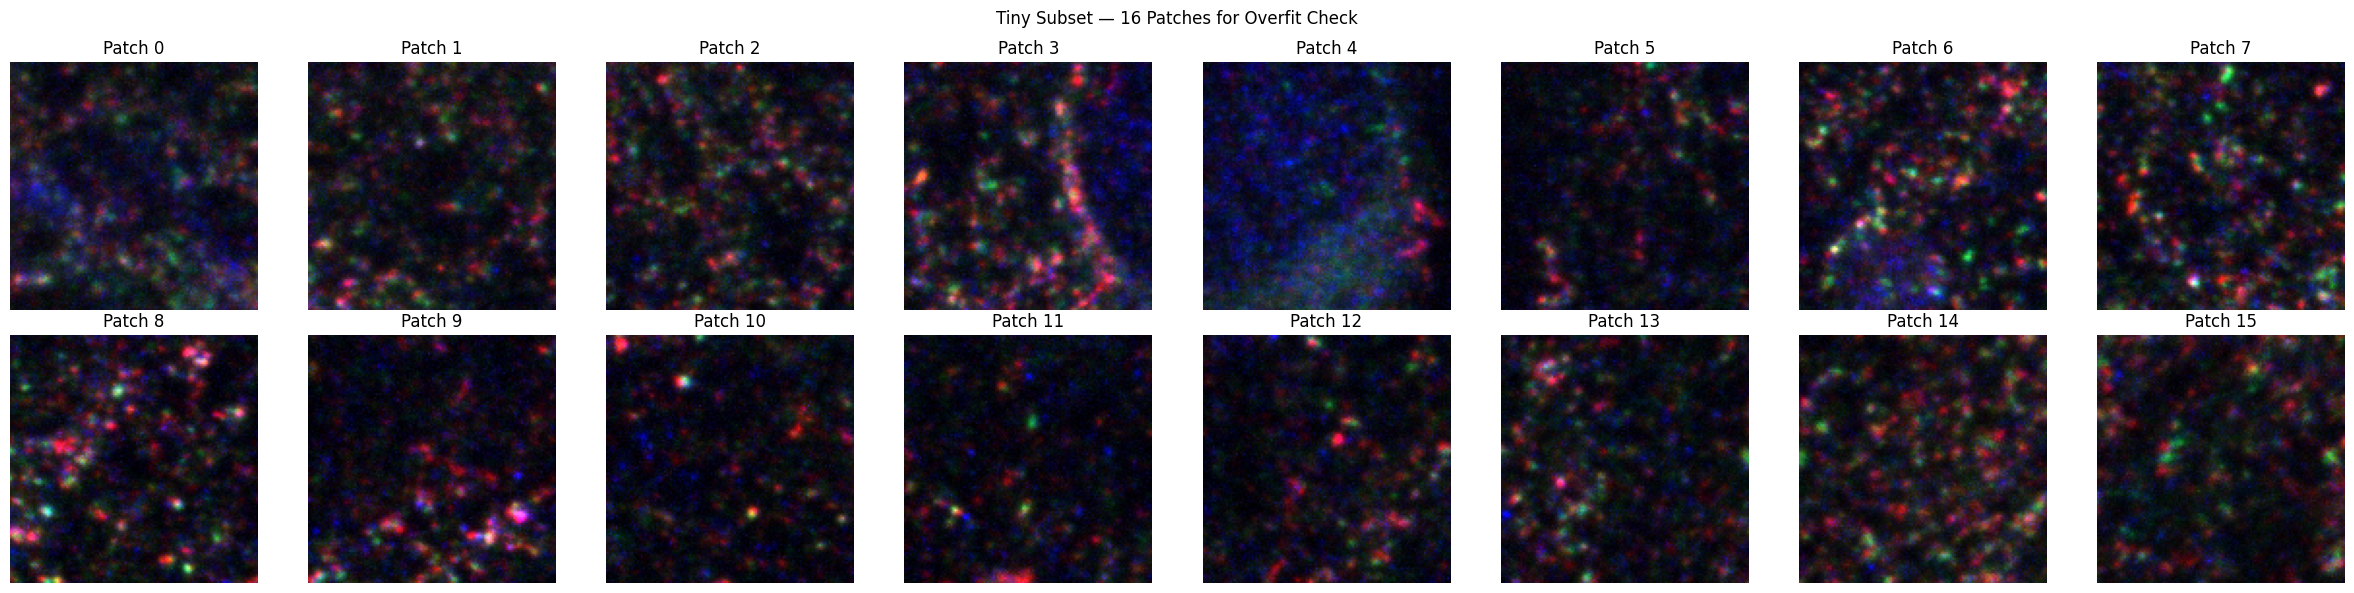

In [11]:
# --- Overfit on 16 patches ---
tiny = Subset(dataset, range(16))
tiny_loader = DataLoader(tiny, batch_size=16, shuffle=False)

# Visualize the 16 patches
fig, axes = plt.subplots(2, 8, figsize=(24, 6))
for i, ax in enumerate(axes.flat):
    patch = tiny[i]
    if patch.shape[0] >= 3:
        ax.imshow(patch[:3].permute(1, 2, 0).numpy())
    else:
        ax.imshow(patch[0].numpy(), cmap="gray")
    ax.set_title(f"Patch {i}")
    ax.axis("off")
plt.suptitle("Tiny Subset \u2014 16 Patches for Overfit Check")
plt.tight_layout()
plt.show()

In [12]:
# Debug: check actual feature shapes from encoder
model.eval()
with torch.no_grad():
    dummy = torch.randn(1, args.in_channels, args.img_size, args.img_size).to(device)
    features = model.swinViT(dummy)
    for i, f in enumerate(features):
        print(f"s{i}: {f.shape}")
    z = model.encode(dummy)
    print(f"latent z: {z.shape}")

s0: torch.Size([1, 48, 64, 64])
s1: torch.Size([1, 96, 32, 32])
s2: torch.Size([1, 192, 16, 16])
s3: torch.Size([1, 384, 8, 8])
s4: torch.Size([1, 768, 4, 4])
latent z: torch.Size([1, 768, 4, 4])


In [13]:
# Overfit sanity check: verify the model can memorize 4 patches
model.train()
opt_test = torch.optim.Adam(model.parameters(), lr=5e-4)
# x_fixed = next(iter(tiny_loader))[:4].to(device)
x_fixed = torch.stack([dataset[0], dataset[100], dataset[200], dataset[300]]).to(device)

scaler_test = torch.amp.GradScaler(device.type, enabled=device.type == "cuda")

# Stop when loss improvement over last 50 steps is negligible
max_steps = 2000
check_every = 25
plateau_window = 100  # compare current loss to loss 100 steps ago
plateau_threshold = 1e-4  # minimum relative improvement to continue
loss_history = []

for step in tqdm(range(max_steps), desc="Overfit"):
    opt_test.zero_grad(set_to_none=True)
    with torch.amp.autocast(device.type, enabled=device.type == "cuda"):
        recon = model(x_fixed)
        loss = weighted_mse_loss(recon, x_fixed, args.bright_weight)
    scaler_test.scale(loss).backward()
    scaler_test.step(opt_test)
    scaler_test.update()

    current_loss = loss.item()
    loss_history.append(current_loss)

    if step % check_every == 0:
        tqdm.write(f"Step {step:4d} | Weighted MSE: {current_loss:.6f}")

print(f"Final loss: {loss_history[-1]:.6f} after {len(loss_history)} steps")

Overfit:   0%|          | 0/2000 [00:00<?, ?it/s]

Step    0 | Weighted MSE: 0.347820
Step   25 | Weighted MSE: 0.094979
Step   50 | Weighted MSE: 0.069104
Step   75 | Weighted MSE: 0.062447
Step  100 | Weighted MSE: 0.059275
Step  125 | Weighted MSE: 0.056439
Step  150 | Weighted MSE: 0.054471
Step  175 | Weighted MSE: 0.053042
Step  200 | Weighted MSE: 0.052062
Step  225 | Weighted MSE: 0.051404
Step  250 | Weighted MSE: 0.050975
Step  275 | Weighted MSE: 0.050657
Step  300 | Weighted MSE: 0.050466
Step  325 | Weighted MSE: 0.049119
Step  350 | Weighted MSE: 0.029703
Step  375 | Weighted MSE: 0.015393
Step  400 | Weighted MSE: 0.009184
Step  425 | Weighted MSE: 0.006004
Step  450 | Weighted MSE: 0.004586
Step  475 | Weighted MSE: 0.003711
Step  500 | Weighted MSE: 0.003120
Step  525 | Weighted MSE: 0.002789
Step  550 | Weighted MSE: 0.002262
Step  575 | Weighted MSE: 0.001962
Step  600 | Weighted MSE: 0.001915
Step  625 | Weighted MSE: 0.001568
Step  650 | Weighted MSE: 0.001447
Step  675 | Weighted MSE: 0.001914
Step  700 | Weighted

In [14]:
import json
from datetime import datetime

# Save overfit checkpoint + experiment log
overfit_ckpt_path = os.path.join(args.save_dir, "overfit_sanity_check.pt")
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": opt_test.state_dict(),
    "overfit_steps": len(loss_history),
    "final_loss": loss_history[-1],
}, overfit_ckpt_path)
print(f"Saved overfit checkpoint: {overfit_ckpt_path}")

# Compute reconstructions for per-sample MSE
model.eval()
with torch.no_grad():
    recons = model(x_fixed)

run_tag = "early_stop"
# Write experiment log
log = {
    "timestamp": datetime.now().isoformat(),
    "run_tag": run_tag,
    "experiment_counter": args.experiment_counter,
    "experiment": "overfit_sanity_check",
    "model": "AESwinPretrainer",
    "config": {k: v for k, v in vars(args).items() if isinstance(v, (int, float, str, bool))},
    "overfit": {
        "n_samples": len(x_fixed),
        "steps": len(loss_history),
        "optimizer": "Adam",
        "lr": 5e-4,
        "final_weighted_mse": loss_history[-1],
        "per_sample_mse": [
            ((recons[i] - x_fixed[i]) ** 2).mean().item()
            for i in range(len(x_fixed))
        ],
    },
    "device": str(device),
}

log_path = os.path.join(args.save_dir, f"overfit_{run_tag}_log.json")
with open(log_path, "w") as f:
    json.dump(log, f, indent=2)
print(f"Saved experiment log: {log_path}")
print(f"Run: {run_tag} (counter={args.experiment_counter})")

Saved overfit checkpoint: ./outputs/pretrain_ae_swin_2026_04_26_191727/overfit_sanity_check.pt
Saved experiment log: ./outputs/pretrain_ae_swin_2026_04_26_191727/overfit_early_stop_log.json
Run: early_stop (counter=0)


In [15]:
model.eval()
with torch.no_grad():
    recons = model(x_fixed)
    
    per_sample_mse = ((recons - x_fixed) ** 2).mean(dim=(1,2,3))
    for i, mse in enumerate(per_sample_mse):
        print(f"Patch {i}: MSE = {mse.item():.6f}")

Patch 0: MSE = 0.000128
Patch 1: MSE = 0.000139
Patch 2: MSE = 0.000118
Patch 3: MSE = 0.000119


In [16]:
# --- Diagnostic: verify reconstructions are distinct (not mode-collapsed) ---
# Reconstruction similarities should roughly mirror original similarities.
# If all recon similarities are ~1.0, the model is ignoring its input.
with torch.no_grad():
    recons = model(x_fixed)
    
    # Pairwise similarity between reconstructions
    n = recons.shape[0]
    recons_flat = recons.reshape(n, -1)
    
    # Also flatten originals for comparison
    orig_flat = x_fixed.reshape(n, -1)
    
    print("=== Pairwise cosine similarity between RECONSTRUCTIONS ===")
    for i in range(n):
        for j in range(i+1, n):
            sim = F.cosine_similarity(recons_flat[i:i+1], recons_flat[j:j+1]).item()
            print(f"  recon[{i}] vs recon[{j}]: {sim:.4f}")
    
    print("\n=== Pairwise cosine similarity between ORIGINALS ===")
    for i in range(n):
        for j in range(i+1, n):
            sim = F.cosine_similarity(orig_flat[i:i+1], orig_flat[j:j+1]).item()
            print(f"  orig[{i}] vs orig[{j}]: {sim:.4f}")

=== Pairwise cosine similarity between RECONSTRUCTIONS ===
  recon[0] vs recon[1]: 0.6105
  recon[0] vs recon[2]: 0.6389
  recon[0] vs recon[3]: 0.7096
  recon[1] vs recon[2]: 0.5255
  recon[1] vs recon[3]: 0.5375
  recon[2] vs recon[3]: 0.6314

=== Pairwise cosine similarity between ORIGINALS ===
  orig[0] vs orig[1]: 0.5965
  orig[0] vs orig[2]: 0.6287
  orig[0] vs orig[3]: 0.6987
  orig[1] vs orig[2]: 0.5126
  orig[1] vs orig[3]: 0.5245
  orig[2] vs orig[3]: 0.6215


In [18]:
with torch.no_grad():
    # Grab an unseen patch
    unseen = dataset[100].unsqueeze(0).to(device)
    
    recon_seen   = model(x_fixed[0:1])       # trained-on patch
    recon_unseen = model(unseen)              # never-seen patch
    
    # If model collapsed, recon_unseen will look like recon_seen
    diff = (recon_seen - recon_unseen).abs().mean().item()
    print(f"Mean abs diff between seen vs unseen reconstruction: {diff:.6f}")

Mean abs diff between seen vs unseen reconstruction: 0.107982


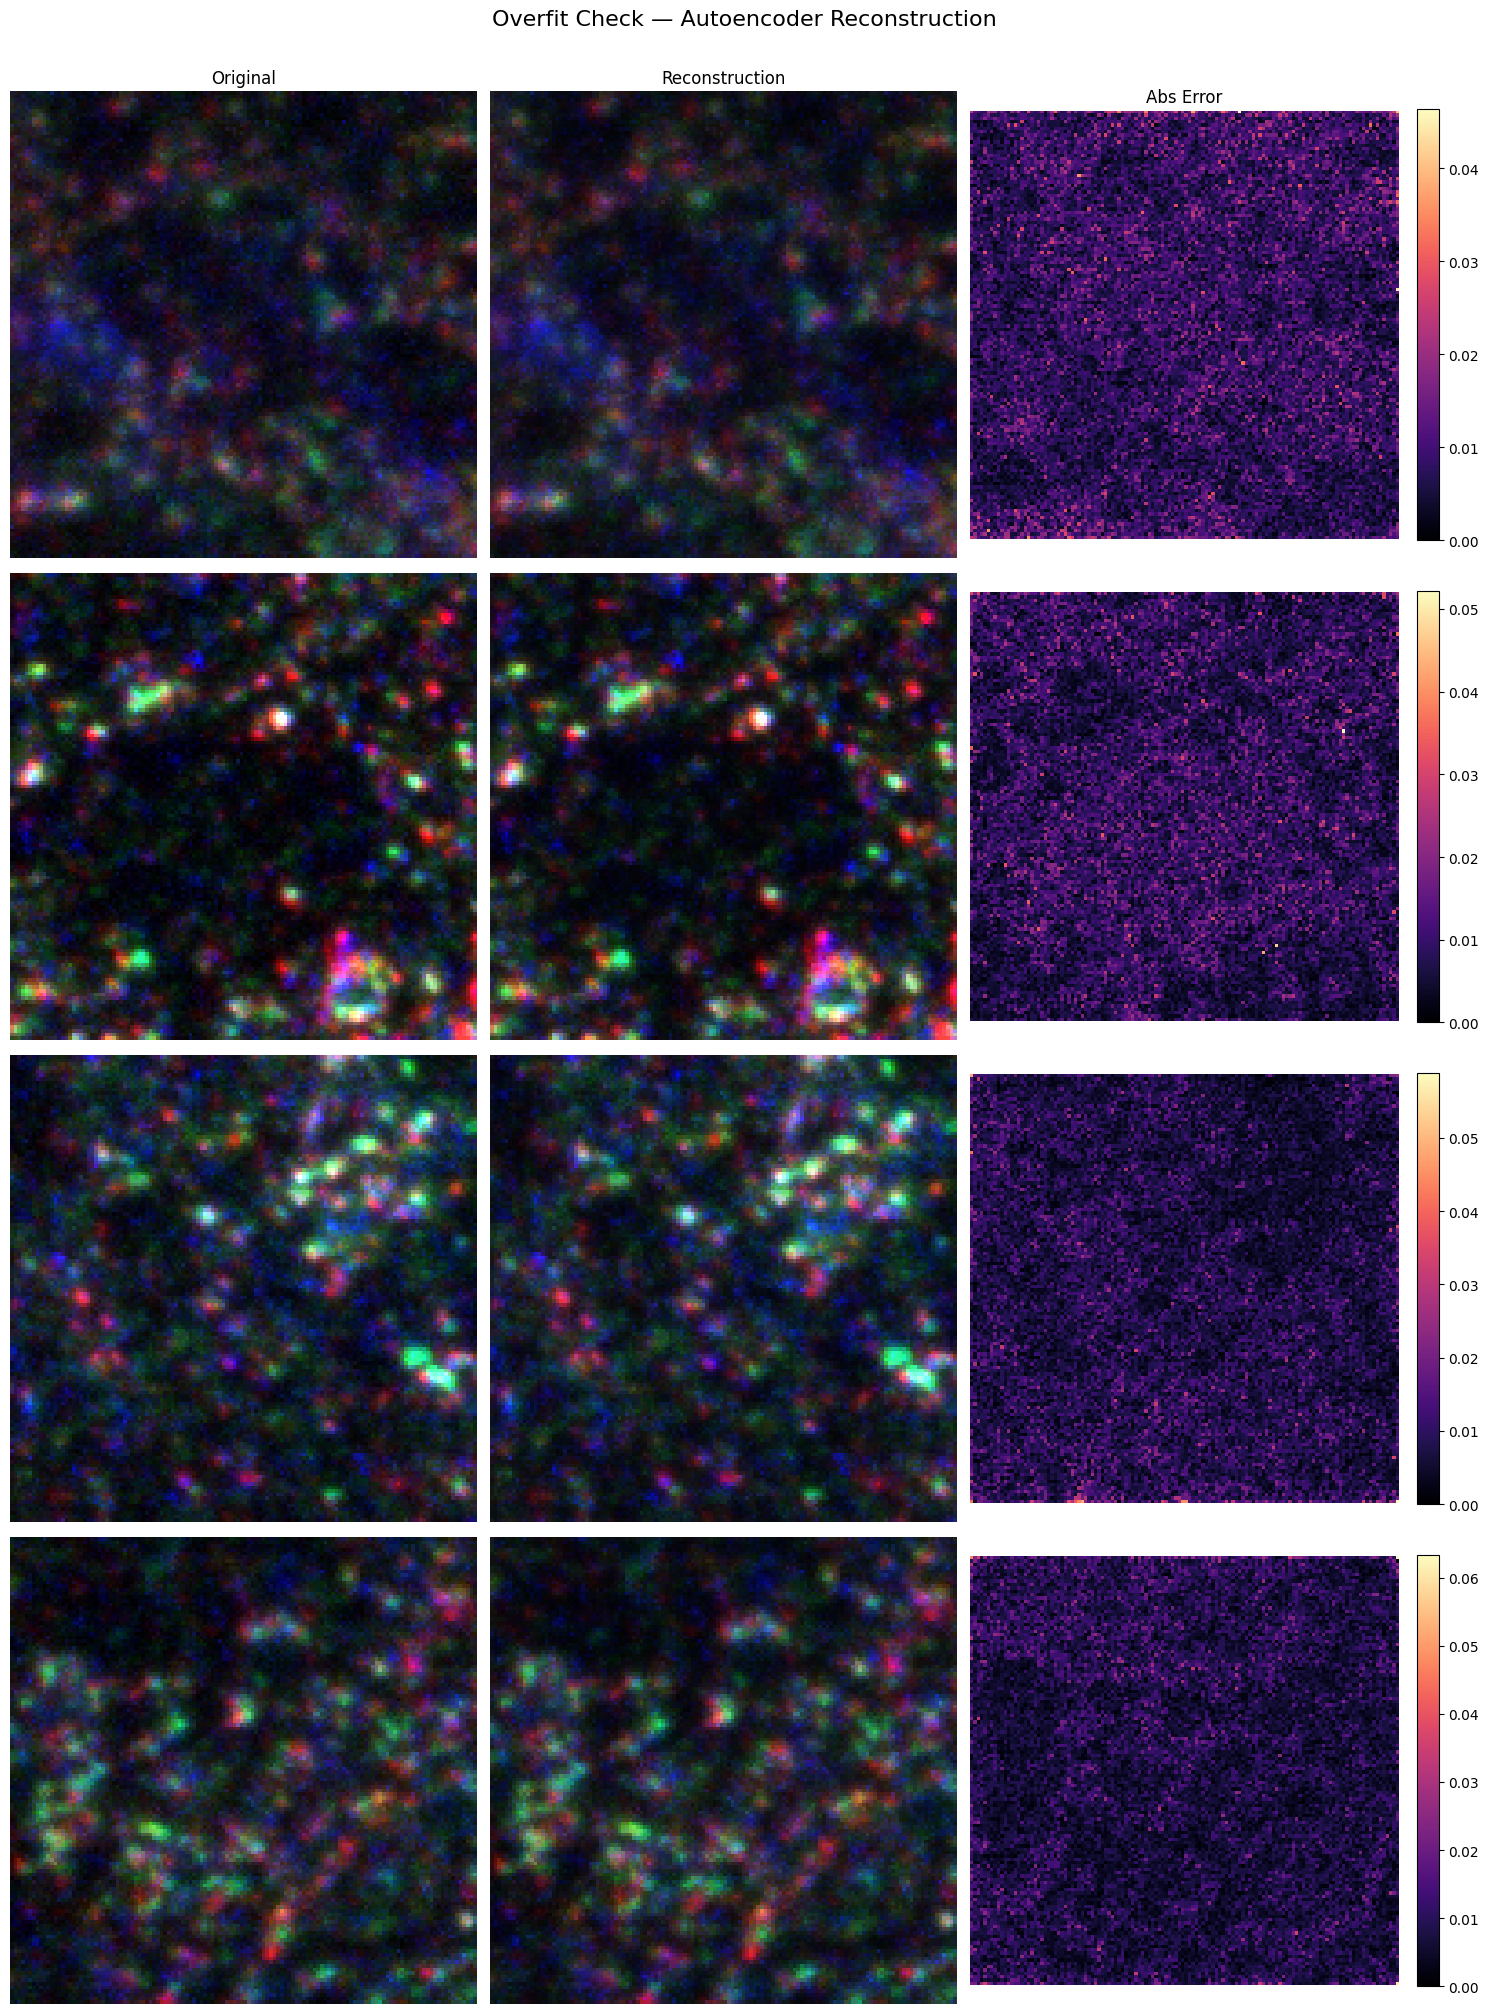

In [19]:
# --- Reconstruction visualization on the 16 overfit patches ---
model.eval()

with torch.no_grad():
    recon = model(x_fixed)

n_show = min(8, len(x_fixed))
fig, axes = plt.subplots(n_show, 3, figsize=(15, n_show * 5))
col_titles = ["Original", "Reconstruction", "Abs Error"]

for i in range(n_show):
    orig = x_fixed[i].cpu()
    rec = recon[i].cpu()

    orig_rgb = orig[:3].permute(1, 2, 0).clamp(0, 1).numpy()
    recon_rgb = rec[:3].permute(1, 2, 0).clamp(0, 1).numpy()
    diff = (orig[:3] - rec[:3]).abs().mean(dim=0).numpy()

    axes[i, 0].imshow(orig_rgb)
    axes[i, 1].imshow(recon_rgb)
    im = axes[i, 2].imshow(diff, cmap="magma", vmin=0, vmax=max(diff.max(), 0.01))
    plt.colorbar(im, ax=axes[i, 2], fraction=0.046, pad=0.04)

    for j, title in enumerate(col_titles):
        if i == 0:
            axes[i, j].set_title(title, fontsize=12)
        axes[i, j].axis("off")

plt.suptitle("Overfit Check \u2014 Autoencoder Reconstruction", fontsize=16, y=1.005)
plt.tight_layout()
plt.show()

## H. Re-initialize Model for Full Training

After verifying the overfit works, re-initialize the model with fresh weights for proper training.

In [21]:
# Fresh model
model = AESwinPretrainer(args).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=args.lr, weight_decay=args.weight_decay)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
print("Model re-initialized for full training.")

Model re-initialized for full training.


## I. Training loop

### TRAINING LOGGING CELLS

In [ ]:
# =====================================================================
# Experiment metadata + CSV logger setup
# =====================================================================

import csv
import json
from datetime import datetime

# Experiment metadata — everything needed to reproduce this run
experiment_meta = {
    "experiment_name":   args.experiment_name,
    "start_time":        datetime.now().isoformat(),
    "device":            str(device),
    "gpu_name":          torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
    "gpu_memory_gb":     round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1) if torch.cuda.is_available() else 0,
    "pytorch_version":   torch.__version__,
    "cuda_version":      torch.version.cuda if torch.cuda.is_available() else "N/A",

    # Data
    "n_train":           len(train_loader.dataset),
    "n_val":             len(val_loader.dataset),
    "n_train_batches":   len(train_loader),
    "n_val_batches":     len(val_loader),
    "patch_size_px":     args.img_size,
    "in_channels":       args.in_channels,

    # Architecture
    "encoder":           "SwinTransformer (MONAI, spatial_dims=2)",
    "feature_size":      args.feature_size,
    "enc_channels":      args.enc_channels,
    "enc_spatial":       args.enc_spatial,
    "window_size":       args.window_size,
    "decoder":           f"ConvTranspose2d x{args.n_dec_upsample} stages",
    "total_params":      sum(p.numel() for p in model.parameters()),
    "encoder_params":    sum(p.numel() for p in model.swinViT.parameters()),
    "decoder_params":    sum(p.numel() for p in model.decoder.parameters()),

    # Training
    "optimizer":         "AdamW",
    "lr":                args.lr,
    "weight_decay":      args.weight_decay,
    "batch_size":        args.batch_size,
    "epochs":            args.epochs,
    "warmup_epochs":     args.warmup_epochs,
    "scheduler":         "linear warmup + cosine decay",
    "bright_weight":     args.bright_weight,
    "loss_fn":           "weighted_mse (bright_weight={})".format(args.bright_weight),
    "mixed_precision":   device.type == "cuda",
    "grad_clip_norm":    1.0,
    "seed":              args.seed,
}

In [ ]:
# Print summary
print("=" * 60)
print(f"Experiment: {experiment_meta['experiment_name']}")
print(f"Device:     {experiment_meta['gpu_name']}")
print(f"Train:      {experiment_meta['n_train']} patches, {experiment_meta['n_train_batches']} batches")
print(f"Val:        {experiment_meta['n_val']} patches, {experiment_meta['n_val_batches']} batches")
print(f"Params:     {experiment_meta['total_params']:,} total "
      f"({experiment_meta['encoder_params']:,} enc + {experiment_meta['decoder_params']:,} dec)")
print("=" * 60)

In [ ]:
# CSV log file — one row per epoch, easy to load later for plots
csv_path = os.path.join(args.save_dir, f"{args.experiment_name}_log.csv")
csv_fields = [
    "epoch", "train_loss", "val_loss", "lr",
    "epoch_time_s", "train_time_s", "val_time_s",
    "best_val_loss", "best_epoch",
    "grad_norm_mean", "grad_norm_max"
]
csv_file = open(csv_path, "w", newline="")
csv_writer = csv.DictWriter(csv_file, fieldnames=csv_fields)
csv_writer.writeheader()

print(f"Logging to: {csv_path}")

### Training

In [ ]:
# =====================================================================
# Training loop with full logging
# =====================================================================

best_val_loss  = float("inf")
best_epoch     = 0
train_losses   = []
val_losses     = []
lr_history     = []
grad_norms     = []   # track gradient health
epoch_times    = []
total_train_start = time.time()

scaler = torch.amp.GradScaler(device.type, enabled=device.type == "cuda")

for epoch in range(1, args.epochs + 1):
    # --- Training ---
    model.train()
    running_loss = 0.0
    epoch_grad_norms = []
    train_start = time.time()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{args.epochs} [train]", leave=False)
    for batch_idx, x in enumerate(pbar, 1):
        x = x.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device.type, enabled=device.type == "cuda"):
            recon = model(x)
            loss  = weighted_mse_loss(recon, x, args.bright_weight)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        # Log gradient norm before clipping
        total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        epoch_grad_norms.append(total_norm.item())

        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        pbar.set_postfix(loss=f"{running_loss / batch_idx:.6f}")

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)
    train_time = time.time() - train_start
    scheduler.step()

    # --- Validation ---
    model.eval()
    val_running_loss = 0.0
    val_start = time.time()

    with torch.no_grad():
        for x in tqdm(val_loader, desc=f"Epoch {epoch}/{args.epochs} [val]", leave=False):
            x = x.to(device, non_blocking=True)
            with torch.amp.autocast(device.type, enabled=device.type == "cuda"):
                recon = model(x)
                loss  = weighted_mse_loss(recon, x, args.bright_weight)
            val_running_loss += loss.item()

    val_loss = val_running_loss / len(val_loader)
    val_losses.append(val_loss)
    val_time = time.time() - val_start

    # --- Bookkeeping ---
    current_lr = scheduler.get_last_lr()[0]
    lr_history.append(current_lr)
    epoch_time = train_time + val_time
    epoch_times.append(epoch_time)
    mean_grad = sum(epoch_grad_norms) / len(epoch_grad_norms)
    max_grad  = max(epoch_grad_norms)
    grad_norms.append(mean_grad)

    improved = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        improved = " *best*"
        torch.save({
            "epoch":               epoch,
            "model_state_dict":    model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "val_loss":            val_loss,
            "train_loss":          train_loss,
            "args":                vars(args),
        }, os.path.join(args.save_dir, "best_ae_model.pt"))

    # Periodic checkpoint every 25 epochs
    if epoch % 25 == 0:
        torch.save({
            "epoch":            epoch,
            "model_state_dict": model.state_dict(),
            "val_loss":         val_loss,
            "train_loss":       train_loss,
        }, os.path.join(args.save_dir, f"ae_epoch_{epoch}.pt"))

    # Print epoch summary
    print(f"Epoch {epoch:3d}/{args.epochs} | "
          f"Train: {train_loss:.6f} | Val: {val_loss:.6f} | "
          f"LR: {current_lr:.2e} | Grad: {mean_grad:.2f} | "
          f"{epoch_time:.1f}s{improved}")

    # Write CSV row
    csv_writer.writerow({
        "epoch":          epoch,
        "train_loss":     f"{train_loss:.8f}",
        "val_loss":       f"{val_loss:.8f}",
        "lr":             f"{current_lr:.2e}",
        "epoch_time_s":   f"{epoch_time:.1f}",
        "train_time_s":   f"{train_time:.1f}",
        "val_time_s":     f"{val_time:.1f}",
        "best_val_loss":  f"{best_val_loss:.8f}",
        "best_epoch":     best_epoch,
        "grad_norm_mean": f"{mean_grad:.4f}",
        "grad_norm_max":  f"{max_grad:.4f}",
    })
    csv_file.flush()  # flush every epoch so data survives crashes

total_train_time = time.time() - total_train_start
print(f"\nTraining complete in {total_train_time/3600:.2f} hours.")
print(f"Best val loss: {best_val_loss:.6f} at epoch {best_epoch}")
csv_file.close()

### Save experiment summary JSON

In [ ]:
experiment_meta["end_time"]         = datetime.now().isoformat()
experiment_meta["total_time_hours"] = round(total_train_time / 3600, 2)
experiment_meta["total_time_s"]     = round(total_train_time, 1)
experiment_meta["avg_epoch_time_s"] = round(sum(epoch_times) / len(epoch_times), 1)
experiment_meta["best_val_loss"]    = best_val_loss
experiment_meta["best_epoch"]       = best_epoch
experiment_meta["final_train_loss"] = train_losses[-1]
experiment_meta["final_val_loss"]   = val_losses[-1]

json_path = os.path.join(args.save_dir, f"{args.experiment_name}_meta.json")
with open(json_path, "w") as f:
    json.dump(experiment_meta, f, indent=2, default=str)
print(f"Saved experiment metadata: {json_path}")

## J  Plateau detection + summary

In [ ]:
import numpy as np

def detect_plateau(losses, window=10, threshold=0.001):
    """Find the epoch where val loss stops improving meaningfully.

    Computes relative improvement over a sliding window.
    Plateau = first epoch where improvement drops below threshold
    for `window` consecutive epochs.
    """
    if len(losses) < window + 1:
        return len(losses), "too few epochs"

    for i in range(window, len(losses)):
        recent = losses[i - window : i]
        best_before = min(losses[:i - window]) if i > window else losses[0]
        best_recent = min(recent)
        rel_improvement = (best_before - best_recent) / (best_before + 1e-12)

        if rel_improvement < threshold:
            return i - window + 1, f"{rel_improvement:.6f}"  # epoch is 1-indexed later

    return len(losses), "no plateau detected"

In [ ]:
plateau_epoch, plateau_info = detect_plateau(val_losses, window=10, threshold=0.001)

print("=" * 60)
print("TRAINING SUMMARY (for thesis)")
print("=" * 60)
print(f"Total epochs:         {len(train_losses)}")
print(f"Total training time:  {total_train_time/3600:.2f} hours ({total_train_time:.0f}s)")
print(f"Avg epoch time:       {sum(epoch_times)/len(epoch_times):.1f}s")
print(f"")
print(f"Best val loss:        {best_val_loss:.6f} at epoch {best_epoch}")
print(f"Final train loss:     {train_losses[-1]:.6f}")
print(f"Final val loss:       {val_losses[-1]:.6f}")
print(f"Train/val gap:        {val_losses[-1] - train_losses[-1]:.6f}")
print(f"")
print(f"Plateau detected:     epoch ~{plateau_epoch} (rel_improv: {plateau_info})")
print(f"Loss at plateau:      train={train_losses[plateau_epoch-1]:.6f}, "
      f"val={val_losses[plateau_epoch-1]:.6f}")
print(f"")
print(f"Initial train loss:   {train_losses[0]:.6f}")
print(f"Initial val loss:     {val_losses[0]:.6f}")
print(f"Total reduction:      {(1 - val_losses[-1]/val_losses[0])*100:.1f}%")
print("=" * 60)

In [ ]:
# =====================================================================
# Loss curve plots
# =====================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
epochs_range = np.arange(1, len(train_losses) + 1)

# --- Panel 1: Linear scale with plateau marker ---
ax = axes[0]
ax.plot(epochs_range, train_losses, label="Train", linewidth=1.5)
ax.plot(epochs_range, val_losses, label="Validation", linewidth=1.5)
ax.axvline(x=plateau_epoch, color="red", linestyle="--", alpha=0.7, label=f"Plateau (~epoch {plateau_epoch})")
ax.axvline(x=best_epoch, color="green", linestyle=":", alpha=0.7, label=f"Best (epoch {best_epoch})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Weighted MSE Loss")
ax.set_title("Training Convergence")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

In [ ]:
# --- Panel 2: Log scale (shows early rapid descent) ---
ax = axes[1]
ax.semilogy(epochs_range, train_losses, label="Train", linewidth=1.5)
ax.semilogy(epochs_range, val_losses, label="Validation", linewidth=1.5)
ax.axvline(x=plateau_epoch, color="red", linestyle="--", alpha=0.7)
ax.set_xlabel("Epoch")
ax.set_ylabel("Weighted MSE Loss (log)")
ax.set_title("Loss (log scale)")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

In [ ]:
# --- Panel 3: Learning rate schedule ---
ax = axes[2]
ax.plot(epochs_range, lr_history, color="tab:orange", linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate")
ax.set_title("LR Schedule")
ax.grid(True, alpha=0.3)
ax.ticklabel_format(style="scientific", axis="y", scilimits=(0,0))

plt.tight_layout()
fig_path = os.path.join(args.save_dir, f"{args.experiment_name}_curves.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")


# --- Gradient norm plot (detects training instability) ---
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(epochs_range, grad_norms, color="tab:red", linewidth=1, alpha=0.8)
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean Gradient Norm")
ax.set_title("Gradient Norm per Epoch")
ax.grid(True, alpha=0.3)
plt.tight_layout()
grad_fig_path = os.path.join(args.save_dir, f"{args.experiment_name}_gradnorms.png")
plt.savefig(grad_fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {grad_fig_path}")


# --- Train/val gap plot (detects overfitting) ---
fig, ax = plt.subplots(figsize=(10, 3))
gap = np.array(val_losses) - np.array(train_losses)
ax.plot(epochs_range, gap, color="tab:purple", linewidth=1.5)
ax.axhline(y=0, color="gray", linestyle="-", alpha=0.5)
ax.fill_between(epochs_range, 0, gap, alpha=0.15, color="tab:purple")
ax.set_xlabel("Epoch")
ax.set_ylabel("Val - Train Loss")
ax.set_title("Generalization Gap")
ax.grid(True, alpha=0.3)
plt.tight_layout()
gap_fig_path = os.path.join(args.save_dir, f"{args.experiment_name}_gap.png")
plt.savefig(gap_fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {gap_fig_path}")

## Inspect CSV log (useful after resuming)

In [ ]:
import pandas as pd

df = pd.read_csv(csv_path)
print(f"Log has {len(df)} epochs")
print(f"\nFirst 5 epochs:")
print(df.head().to_string(index=False))
print(f"\nLast 5 epochs:")
print(df.tail().to_string(index=False))
print(f"\nBest epoch by val_loss:")
best_row = df.loc[df["val_loss"].idxmin()]
print(best_row.to_string())

## J. Load a Previous Run (optional)

Skip this section if you just finished training above.  
To resume from a past run, set `load_dir` to the output folder and run the cells below.  
This re-creates the model, loads the checkpoint, and sets `args.save_dir` so all downstream cells (K, L) work.

In [30]:
# ── SET THIS to the folder of a previous run ──
# e.g. "./outputs/pretrain_ae_swin_2026_04_25_143012"
load_dir = "./checkpoints/"  # <-- paste path here, or leave None to use current run

if load_dir is not None:
    assert os.path.isdir(load_dir), f"Directory not found: {load_dir}"
    args.save_dir = load_dir
    print(f"Using previous run: {args.save_dir}")

    # Re-create model (needed if kernel was restarted)
    model = AESwinPretrainer(args).to(device)

    # Load best checkpoint
    ckpt_path = os.path.join(args.save_dir, "best_ae_model.pt")
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"Loaded epoch {ckpt['epoch']} | val_loss: {ckpt['val_loss']:.6f}")
else:
    print(f"No load_dir set — using current run: {args.save_dir}")

Using previous run: ./checkpoints/
Loaded epoch 199 | val_loss: 0.003894


### Dimensional Collapse Diagnostic

Check whether the encoder's latent representations suffer from **dimensional collapse** — where only a few dimensions carry information and the rest are dead.

**Method:** Encode many patches → center → SVD → inspect singular value spectrum.  
- If top 5–10 singular values dominate and the rest drop off a cliff → **collapse**.  
- **Effective rank** = exp(entropy of normalised squared singular values). If effective rank ≪ D, collapse is present.

In [34]:
# --- Dimensional Collapse Diagnostic ---
val_subset = Subset(val_loader.dataset, list(range(min(2048, len(val_loader.dataset)))))
diag_loader = DataLoader(val_subset, batch_size=args.batch_size, shuffle=False)

model.eval()
latents = []
with torch.no_grad():
    for x in tqdm(diag_loader, desc="Encoding for collapse check"):
        x = x.to(device, non_blocking=True)
        z = model.encode(x)
        latents.append(z.flatten(1).cpu())

Z = torch.cat(latents, dim=0)           # (N, D)
N, D = Z.shape
ceiling = min(N, D)                     # rank ceiling
print(f"Latent matrix Z: {Z.shape}  (N={N}, D={D}, ceiling={ceiling})")

# Center
Z = Z - Z.mean(dim=0, keepdim=True)

# SVD
_, S, _ = torch.svd(Z)
S_norm = S / S[0]

# Effective rank = exp(entropy of squared singular values)
s2 = (S ** 2) / (S ** 2).sum()
log_s2 = torch.log(s2 + 1e-12)
eff_rank = torch.exp(-(s2 * log_s2).sum()).item()

print(f"Top-10 normalised singular values: "
      f"{[f'{v:.3f}' for v in S_norm[:10].tolist()]}")
print(f"Effective rank: {eff_rank:.1f} / {ceiling}  "
      f"({eff_rank / ceiling * 100:.1f}% of capacity)")

# Use rank-ceiling-relative thresholds, not D-relative
if eff_rank / ceiling < 0.05:
    print("WARNING: severe collapse  (< 5% of capacity used)")
elif eff_rank / ceiling < 0.30:
    print("CAUTION: moderate collapse  (< 30% of capacity used)")
else:
    print("OK: no significant collapse")

Encoding for collapse check:   0%|          | 0/64 [00:00<?, ?it/s]

Latent matrix Z: torch.Size([2048, 12288])  (N=2048, D=12288, ceiling=2048)
Top-10 normalised singular values: ['1.000', '0.491', '0.454', '0.364', '0.347', '0.336', '0.331', '0.324', '0.311', '0.304']
Effective rank: 1124.9 / 2048  (54.9% of capacity)
OK: no significant collapse


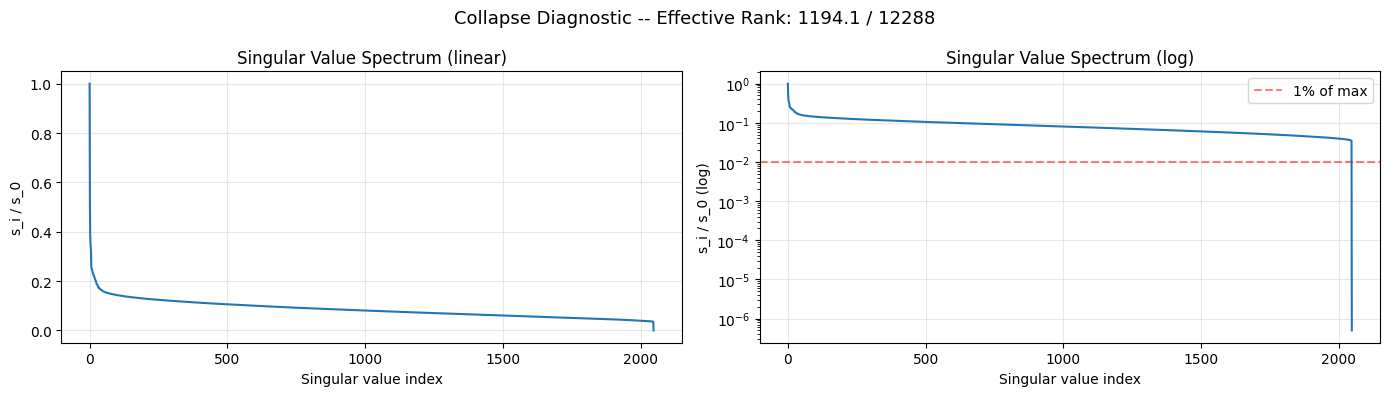

In [32]:
# --- Singular value spectrum plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Linear scale
axes[0].plot(S_norm.numpy(), linewidth=1.5)
axes[0].set_xlabel("Singular value index")
axes[0].set_ylabel("s_i / s_0")
axes[0].set_title("Singular Value Spectrum (linear)")
axes[0].grid(True, alpha=0.3)

# Log scale -- reveals the cliff / tail behaviour
axes[1].semilogy(S_norm.numpy(), linewidth=1.5)
axes[1].set_xlabel("Singular value index")
axes[1].set_ylabel("s_i / s_0 (log)")
axes[1].set_title("Singular Value Spectrum (log)")
axes[1].axhline(y=0.01, color="red", linestyle="--", alpha=0.5, label="1% of max")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f"Collapse Diagnostic -- Effective Rank: {effective_rank:.1f} / {D_lat}", fontsize=13)
plt.tight_layout()
plt.show()

## K. Save Pretrained Encoder

Extract and save only the `swinViT` encoder weights from the best checkpoint.  
The decoder is discarded — only the encoder is transferred to SwinUNETR for segmentation fine-tuning.

In [ ]:
# Load best checkpoint from training
best_ckpt_path = os.path.join(args.save_dir, "best_ae_model.pt")
best_ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(best_ckpt["model_state_dict"])
print(f"Loaded best model from epoch {best_ckpt['epoch']} "
      f"(val_loss: {best_ckpt['val_loss']:.6f})")

# Save encoder-only weights (decoder is discarded)
encoder_path = os.path.join(args.save_dir, args.encoder_save_name)
torch.save(model.swinViT.state_dict(), encoder_path)
print(f"Saved pretrained encoder: {encoder_path}")
print(f"Encoder keys: {len(model.swinViT.state_dict())} parameters")

# Save config alongside encoder for reproducibility
import json as _json
cfg_path = os.path.join(args.save_dir, "pretrain_ae_config.json")
with open(cfg_path, "w") as f:
    _json.dump({
        k: v for k, v in vars(args).items()
        if isinstance(v, (int, float, str, bool))
    }, f, indent=2)
print(f"Saved config: {cfg_path}")

In [ ]:
# --- Transfer recipe for SwinUNETR ---
print("=" * 60)
print("TRANSFER RECIPE — paste into segmentation notebook:")
print("=" * 60)
print(f"""
from monai.networks.nets import SwinUNETR

seg_model = SwinUNETR(
    img_size={args.img_size},
    in_channels={args.in_channels},
    out_channels=1,
    feature_size={args.feature_size},
    spatial_dims=2,
)

encoder_weights = torch.load("{encoder_path}", map_location=device)
seg_model.swinViT.load_state_dict(encoder_weights, strict=True)
print("Pretrained encoder loaded into SwinUNETR.")
""")

## L. Final Validation & Visualization

In [ ]:
model.eval()
final_val_loss = 0.0
with torch.no_grad():
    for x in val_loader:
        x = x.to(device)
        recon = model(x)
        loss = weighted_mse_loss(recon, x, args.bright_weight)
        final_val_loss += loss.item()

final_val_loss /= len(val_loader)
print(f"Final validation loss (best model): {final_val_loss:.6f}")

# Visualize reconstruction on validation samples
with torch.no_grad():
    sample_batch = next(iter(val_loader))[:4].to(device)
    sample_recon = model(sample_batch)

fig, axes = plt.subplots(4, 3, figsize=(15, 20))
col_titles = ["Original", "Reconstruction", "Abs Error"]

for i in range(4):
    orig = sample_batch[i].cpu()
    rec = sample_recon[i].cpu()

    orig_rgb = orig[:3].permute(1, 2, 0).clamp(0, 1).numpy()
    recon_rgb = rec[:3].permute(1, 2, 0).clamp(0, 1).numpy()
    diff = (orig[:3] - rec[:3]).abs().mean(dim=0).numpy()

    axes[i, 0].imshow(orig_rgb)
    axes[i, 1].imshow(recon_rgb)
    im = axes[i, 2].imshow(diff, cmap="hot", vmin=0, vmax=max(diff.max(), 0.01))
    plt.colorbar(im, ax=axes[i, 2], fraction=0.046, pad=0.04)

    for j, title in enumerate(col_titles):
        if i == 0:
            axes[i, j].set_title(title, fontsize=12)
        axes[i, j].axis("off")

plt.suptitle(f"Autoencoder Reconstruction Quality — Val Loss: {final_val_loss:.6f}", fontsize=14)
plt.tight_layout()
plt.show()